In [10]:
import numpy as np

# ==========================================
# 1. HYPERPARAMETERS (Matching your robot)
# ==========================================
INPUT_DIM = 48         # 16 joints * 3 variables (K, D, tau_ff)
TIMESTEPS = 90         # Number of control ticks in one gait cycle
N_RES = 100            # Number of neurons in the reservoir
LEAK_RATE = 0.3        # How fast the network "forgets" (0.0 to 1.0)
SPECTRAL_RADIUS = 0.9  # Keeps the echoes from exploding to infinity
RIDGE_REG_LAMBDA = 0.01# Regularization to prevent overfitting

# ==========================================
# 2. HELPER: SYNTHETIC DATA GENERATOR
# ==========================================
def generate_gait_data(num_samples):
    """
    Simulates your 0.9s gait cycle data for two different 'surfaces'.
    Class 0 (e.g., Concrete): Fast, high-frequency stiffness fluctuations.
    Class 1 (e.g., Grass): Slow, smooth, highly-damped waves.
    """
    X_data = []
    Y_labels = []
    
    for _ in range(num_samples):
        # Randomly choose a surface type (0 or 1)
        surface_type = np.random.randint(0, 2)
        
        # Create an empty matrix for the 90-timestep gait cycle
        gait_cycle = np.zeros((TIMESTEPS, INPUT_DIM))
        
        time_axis = np.linspace(0, 2 * np.pi, TIMESTEPS)
        
        if surface_type == 0: # "Concrete"
            # High frequency sine waves + low noise
            for dim in range(INPUT_DIM):
                freq = np.random.uniform(3.0, 5.0)
                gait_cycle[:, dim] = np.sin(freq * time_axis) + np.random.normal(0, 0.1, TIMESTEPS)
            label = [1, 0] # One-hot encoded [Concrete, Grass]
            
        else: # "Grass"
            # Low frequency sine waves + high noise (representing compliance)
            for dim in range(INPUT_DIM):
                freq = np.random.uniform(0.5, 1.5)
                gait_cycle[:, dim] = np.sin(freq * time_axis) + np.random.normal(0, 0.4, TIMESTEPS)
            label = [0, 1] 
            
        X_data.append(gait_cycle)
        Y_labels.append(label)
        
    return np.array(X_data), np.array(Y_labels)

# ==========================================
# 3. ESN INITIALIZATION
# ==========================================
print("Initializing Reservoir...")
# Random input weights (-0.1 to 0.1)
W_in = np.random.uniform(-0.1, 0.1, (N_RES, INPUT_DIM))

# Random internal weights
W_res = np.random.uniform(-1.0, 1.0, (N_RES, N_RES))
# print(np.shape(W_res))
# Scale W_res by its spectral radius (largest eigenvalue)
eigenvalues = np.linalg.eigvals(W_res)
# print(np.shape(eigenvalues))
max_eigenvalue = np.max(np.abs(eigenvalues))
W_res = W_res * (SPECTRAL_RADIUS / max_eigenvalue)

# ==========================================
# 4. THE CORE ESN ENGINE
# ==========================================
def get_reservoir_state(gait_cycle_data):
    """
    Runs a single 90-timestep gait cycle through the reservoir.
    Returns the final 100-dimensional state vector.
    """
    # Start with an empty state
    x = np.zeros(N_RES) 
    
    # Run the loop for the 90 timesteps
    for t in range(TIMESTEPS):
        u_t = gait_cycle_data[t, :] # The 48 sensor readings at time 't'
        
        # The Echo State Update Equation
        x_new = np.tanh(W_in @ u_t + W_res @ x)
        x = (1 - LEAK_RATE) * x + LEAK_RATE * x_new
        
    return x # The final state after 0.9 seconds

# ==========================================
# 5. TRAINING PHASE (Supervised)
# ==========================================
print("Generating 200 Training Gait Cycles...")
X_train_raw, Y_train = generate_gait_data(200)

print("Running Training Data through Reservoir...")
# We will collect the final state 'v' for all 200 cycles
X_train_states = np.zeros((200, N_RES))

for i in range(200):
    final_state = get_reservoir_state(X_train_raw[i])
    X_train_states[i, :] = final_state

print("Solving for Readout Weights (Ridge Regression)...")
# W_out = (X^T X + lambda*I)^-1 X^T Y
I = np.eye(N_RES)
A = X_train_states.T @ X_train_states + RIDGE_REG_LAMBDA * I
B = X_train_states.T @ Y_train

# Solve linear equations natively
W_out_T = np.linalg.solve(A, B)
W_out = W_out_T.T # Shape will be (2 classes, 100 neurons)

print(f"Training Complete! W_out Shape: {W_out.shape}\n")

# ==========================================
# 6. TESTING / INFERENCE PHASE
# ==========================================
print("Generating 50 Unseen Testing Gait Cycles...")
X_test_raw, Y_test_true = generate_gait_data(50)

correct_predictions = 0

for i in range(50):
    # 1. Robot takes a step (processes the 90 timesteps)
    v = get_reservoir_state(X_test_raw[i])
    
    # 2. Instant Classification (Microseconds on RPi4)
    prediction_scores = W_out @ v
    predicted_class = np.argmax(prediction_scores)
    
    # 3. Check accuracy
    true_class = np.argmax(Y_test_true[i])
    if predicted_class == true_class:
        correct_predictions += 1

accuracy = (correct_predictions / 50) * 100
print(f"--- TEST RESULTS ---")
print(f"Accuracy on unseen data: {accuracy:.2f}%")

Initializing Reservoir...
Generating 200 Training Gait Cycles...
Running Training Data through Reservoir...
Solving for Readout Weights (Ridge Regression)...
Training Complete! W_out Shape: (2, 100)

Generating 50 Unseen Testing Gait Cycles...
--- TEST RESULTS ---
Accuracy on unseen data: 58.00%


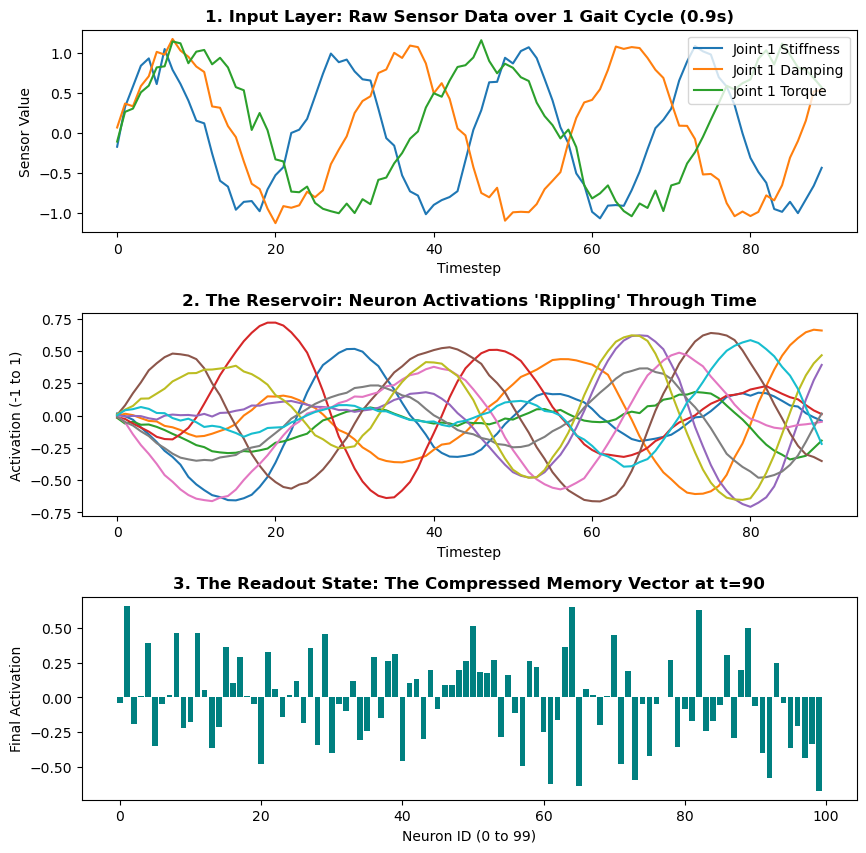

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP & INITIALIZATION
# ==========================================
# (Using the same hyperparameter setup as your RPi4 architecture)
INPUT_DIM = 48
TIMESTEPS = 90
N_RES = 100
LEAK_RATE = 0.3
SPECTRAL_RADIUS = 0.9

np.random.seed(42) # Set seed so the random weights produce the same plot every time

W_in = np.random.uniform(-0.1, 0.1, (N_RES, INPUT_DIM))
W_res = np.random.uniform(-1.0, 1.0, (N_RES, N_RES))
W_res *= (SPECTRAL_RADIUS / np.max(np.abs(np.linalg.eigvals(W_res))))

# ==========================================
# 2. GENERATE A SINGLE GAIT CYCLE INPUT
# ==========================================
# Simulating 90 timesteps of sensor data
time_axis = np.linspace(0, 2 * np.pi, TIMESTEPS)
u_input = np.zeros((TIMESTEPS, INPUT_DIM))

for dim in range(INPUT_DIM):
    freq = np.random.uniform(2.0, 4.0)
    # Sine wave representing cyclical leg movement + sensor noise
    u_input[:, dim] = np.sin(freq * time_axis) + np.random.normal(0, 0.1, TIMESTEPS)

# ==========================================
# 3. RUN THE RESERVOIR & RECORD HISTORY
# ==========================================
state_history = np.zeros((TIMESTEPS, N_RES))
x = np.zeros(N_RES)

# We loop through the 90 ticks, just like the real robot will
for t in range(TIMESTEPS):
    x_new = np.tanh(W_in @ u_input[t, :] + W_res @ x)
    x = (1 - LEAK_RATE) * x + LEAK_RATE * x_new
    
    # Save the state at this millisecond so we can plot it later
    state_history[t, :] = x 

# ==========================================
# 4. PLOTTING THE PROCESS
# ==========================================
fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=False)
plt.subplots_adjust(hspace=0.4)

# --- Plot 1: The Raw Input Signal ---
# We only plot 3 dimensions so it isn't a messy blur of 48 lines
axs[0].plot(u_input[:, 0], label="Joint 1 Stiffness")
axs[0].plot(u_input[:, 1], label="Joint 1 Damping")
axs[0].plot(u_input[:, 2], label="Joint 1 Torque")
axs[0].set_title("1. Input Layer: Raw Sensor Data over 1 Gait Cycle (0.9s)", fontweight='bold')
axs[0].set_xlabel("Timestep")
axs[0].set_ylabel("Sensor Value")
axs[0].legend(loc="upper right")

# --- Plot 2: The Reservoir "Echoes" ---
# Plotting the activations of 10 random neurons over time
for i in range(10): 
    axs[1].plot(state_history[:, i])
axs[1].set_title("2. The Reservoir: Neuron Activations 'Rippling' Through Time", fontweight='bold')
axs[1].set_xlabel("Timestep")
axs[1].set_ylabel("Activation (-1 to 1)")

# --- Plot 3: The Final Readout State ---
# This is a bar chart of the final vector at t=90
axs[2].bar(range(N_RES), state_history[-1, :], color='teal')
axs[2].set_title("3. The Readout State: The Compressed Memory Vector at t=90", fontweight='bold')
axs[2].set_xlabel("Neuron ID (0 to 99)")
axs[2].set_ylabel("Final Activation")

plt.show()